<a href="https://colab.research.google.com/github/Kamal1202/23051_SuryaKamal_PraktikumPBW/blob/main/Segmentasi_Pelanggan_dengan_K_Means_%26_DBScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OUTLIER TEAM 5C - Informatika:**


1.   Farid Noer Hakim (2310631170081)
1.   Rachelia Achmara (2310631170111)
2.   Riva Sestia Praba (2310631170045)
1.   Rolis Liu (2310631170117)
2.   Surya Kamal (2310631170051)
2.   Zaldy Seno Yudhanto (2310631170123)


# **Business Understanding**


---

Memahami tujuan bisnis dan masalah utama yang ingin diselesaikan dari dataset.

Dataset ini berisi data perilaku pelanggan e-commerce yang mencakup informasi transaksi, demografi, dan interaksi pengguna selama berbelanja.
Tujuan analisis adalah untuk:



*   Mengelompokkan pelanggan berdasarkan perilaku dan kebiasaan belanja (customer segmentation).
*   Memahami pola pembelian, loyalitas, dan preferensi pelanggan.
*   Membantu bisnis dalam strategi pemasaran, personalisasi promosi, dan retensi pelanggan.


# **Data Understanding**


---

Memahami karakteristik dan isi data sebelum dilakukan pemrosesan.

Dataset memiliki 18 kolom dan 17.049 baris, mencakup informasi seperti:


*   Data demografis: Age, Gender, City
*   Data transaksi: Unit_Price, Quantity, Discount_Amount, Total_Amount
*   Data perilaku: Session_Duration_Minutes, Pages_Viewed, Is_Returning_Customer
*   Data layanan: Delivery_Time_Days, Customer_Rating

Kesimpulan awal:

*   Tidak ada nilai yang hilang (missing values).
*   Tidak ada data duplikat.
*   Data sudah bersih dan siap dianalisis.
*   Beberapa kolom bertipe kategorikal (object) yang perlu di-encode sebelum diproses.

# **Data Preparation**


---

Tahapan ini meliputi pemilihan EDA, fitur, encoding, normalisasi, dan pembuatan fitur baru (feature engineering).

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zaldysenoyudhanto","key":"63c603133746e77c0a5b8a042713c86b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr

Dataset URL: https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr
License(s): CC0-1.0
  0% 0.00/571k [00:00<?, ?B/s]
100% 571k/571k [00:00<00:00, 768MB/s]


In [ ]:
!mkdir dataset

In [ ]:
!unzip e-commerce-customer-behavior-and-sales-analysis-tr.zip -d dataset

Archive:  e-commerce-customer-behavior-and-sales-analysis-tr.zip
  inflating: dataset/DATASET_README.md  
  inflating: dataset/ecommerce_customer_behavior_dataset.csv  
  inflating: dataset/ecommerce_customer_behavior_dataset_v2.csv  
  inflating: dataset/ecommerce_dataset_readme_v_2.md  


In [ ]:
import pandas as pd

In [ ]:
file = "/content/dataset/ecommerce_customer_behavior_dataset_v2.csv"
df = pd.read_csv(file)

df.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


**Data Preparation**


---

Preprocessing data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Preparation**


---

EDA (Exploratory Data Analysis)

In [ ]:
# Cek informasi data
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nTipe data & non-null count:")
print(df.info())

Jumlah baris: 17049
Jumlah kolom: 18

Tipe data & non-null count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 


In [ ]:
# Cek nilai null
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Date,0
Age,0
Gender,0
City,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount_Amount,0


In [ ]:
# Cek data duplikat
print("Jumlah baris yang terduplikat: ", df.duplicated().sum())

Jumlah baris yang terduplikat:  0


In [ ]:
# Cek nilai statistik data
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


In [ ]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
Female    8613
Male      8176
Other      260
Name: count, dtype: int64


In [ ]:
# Korelasi antar fitur numerik
corr = df.corr(numeric_only=True)
print(corr)

                               Age  Unit_Price  Quantity  Discount_Amount  \
Age                       1.000000   -0.003125  0.001580         0.007049   
Unit_Price               -0.003125    1.000000 -0.001539         0.477427   
Quantity                  0.001580   -0.001539  1.000000         0.128507   
Discount_Amount           0.007049    0.477427  0.128507         1.000000   
Total_Amount             -0.003606    0.866225  0.256567         0.456245   
Session_Duration_Minutes  0.014777   -0.008897 -0.006932        -0.005170   
Pages_Viewed             -0.006901    0.015227 -0.002301        -0.004359   
Is_Returning_Customer     0.002584    0.005009 -0.004509        -0.000757   
Delivery_Time_Days        0.001385   -0.018650  0.000466        -0.009662   
Customer_Rating          -0.003152   -0.002999 -0.003355         0.002004   

                          Total_Amount  Session_Duration_Minutes  \
Age                          -0.003606                  0.014777   
Unit_Price      

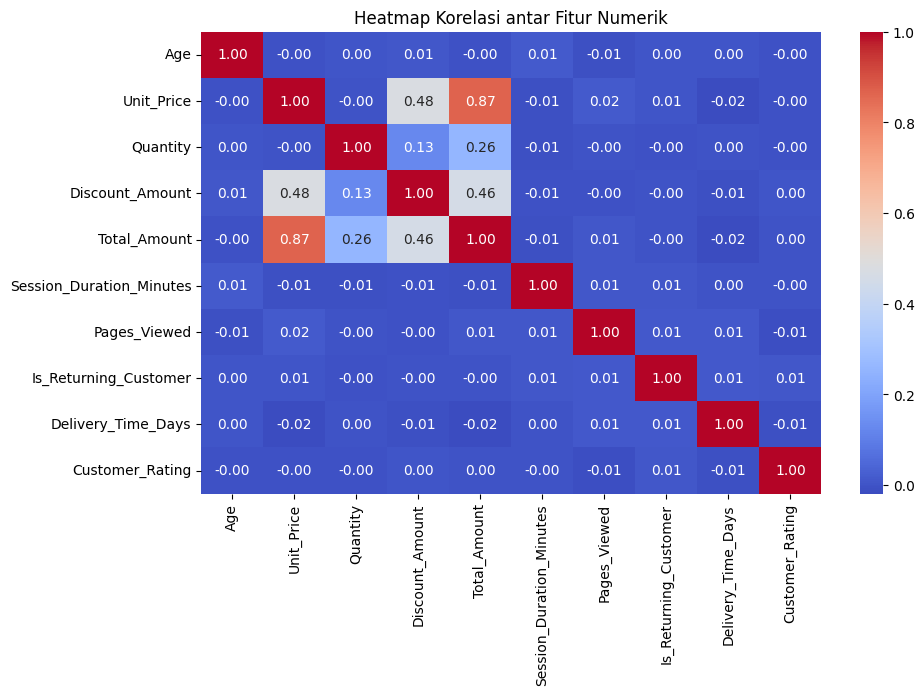

In [ ]:
# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi antar Fitur Numerik")
plt.show()

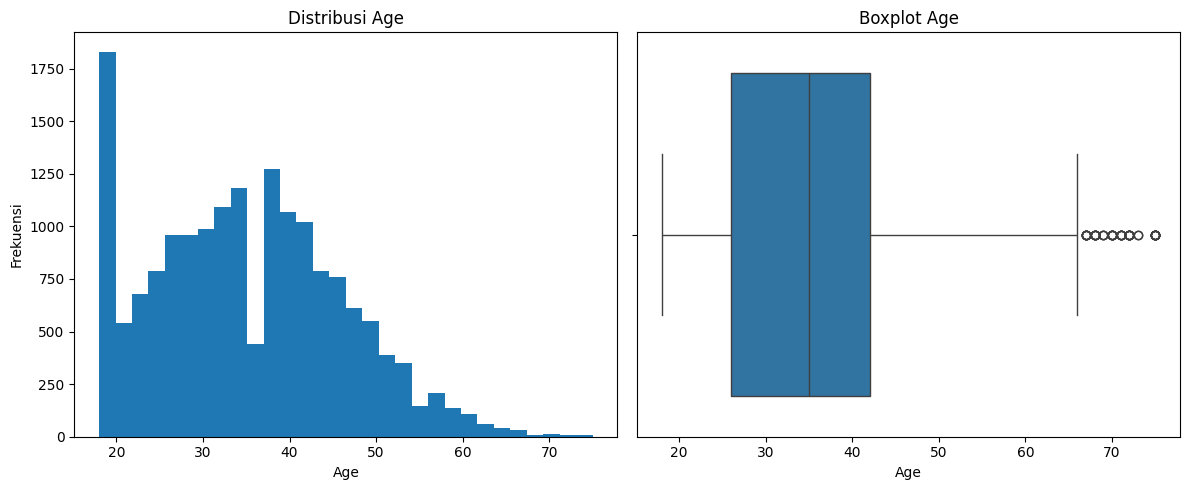

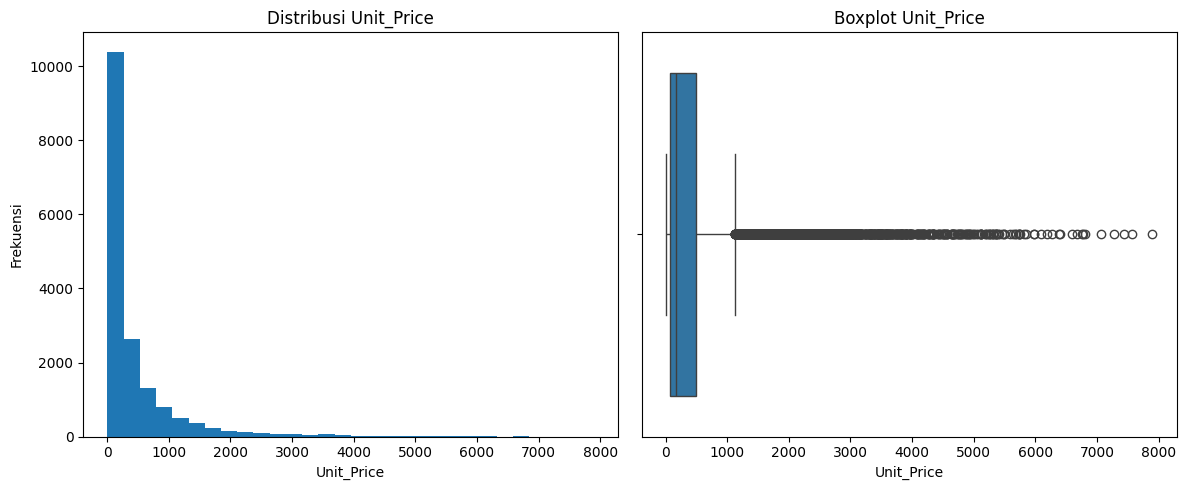

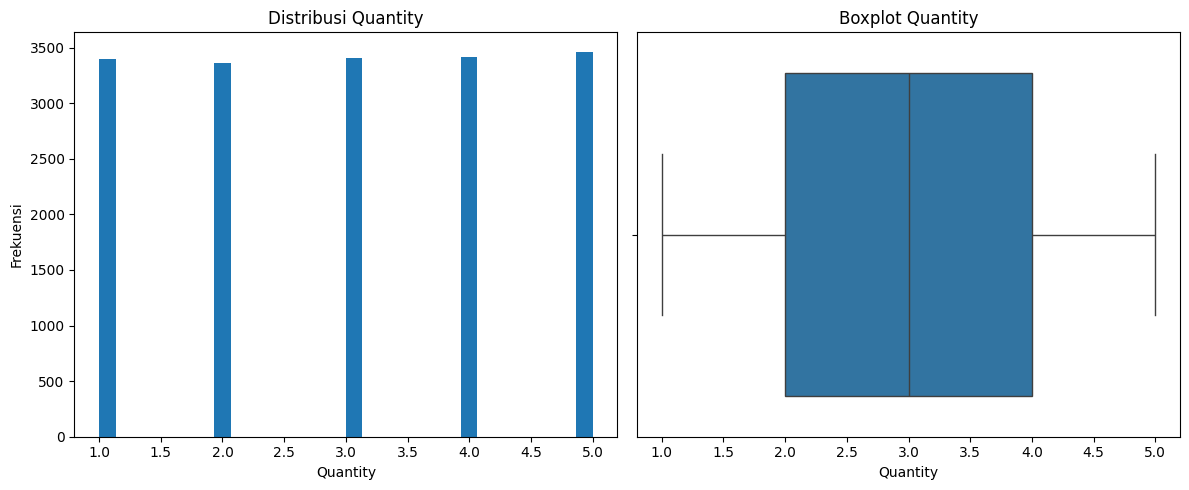

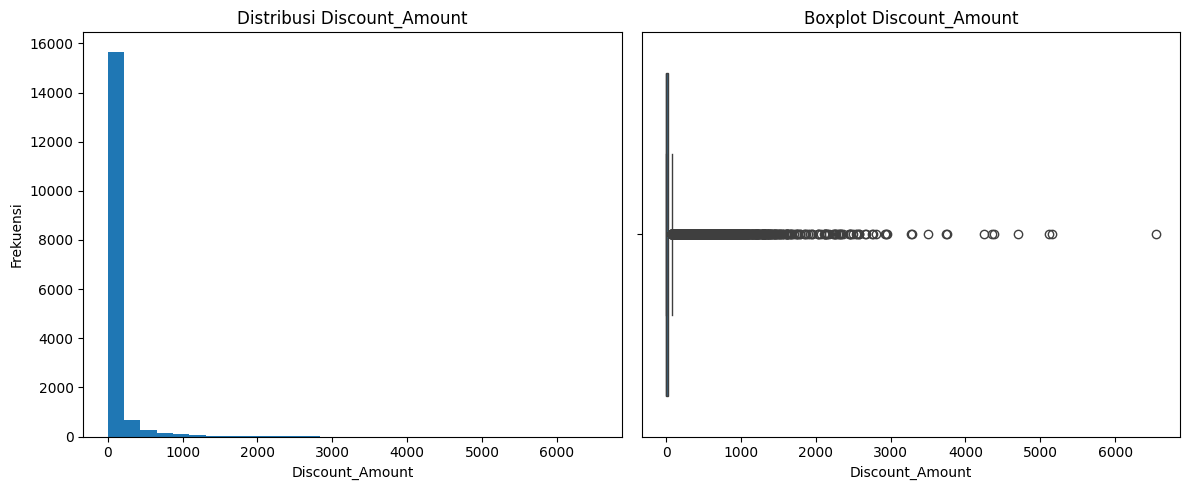

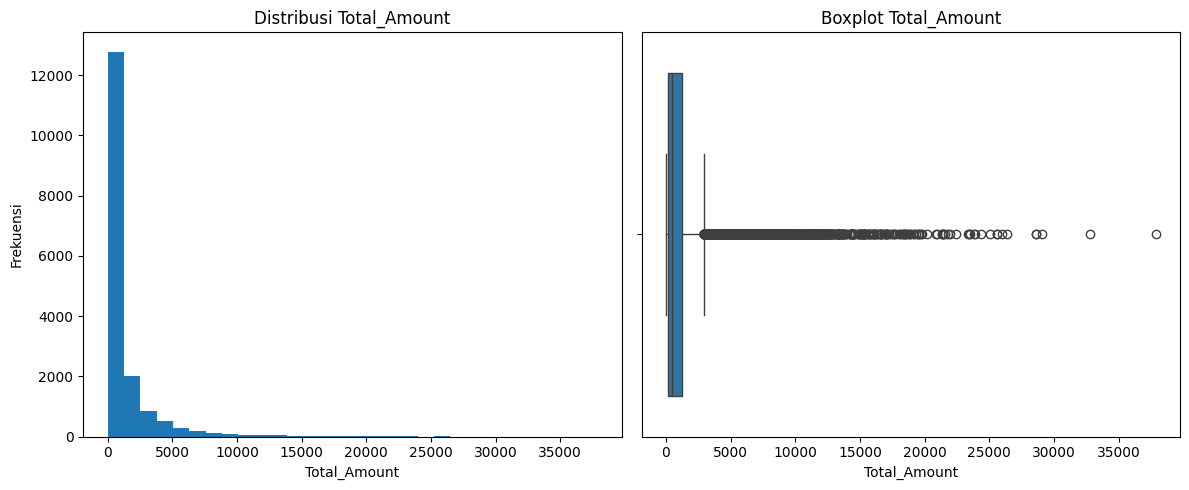

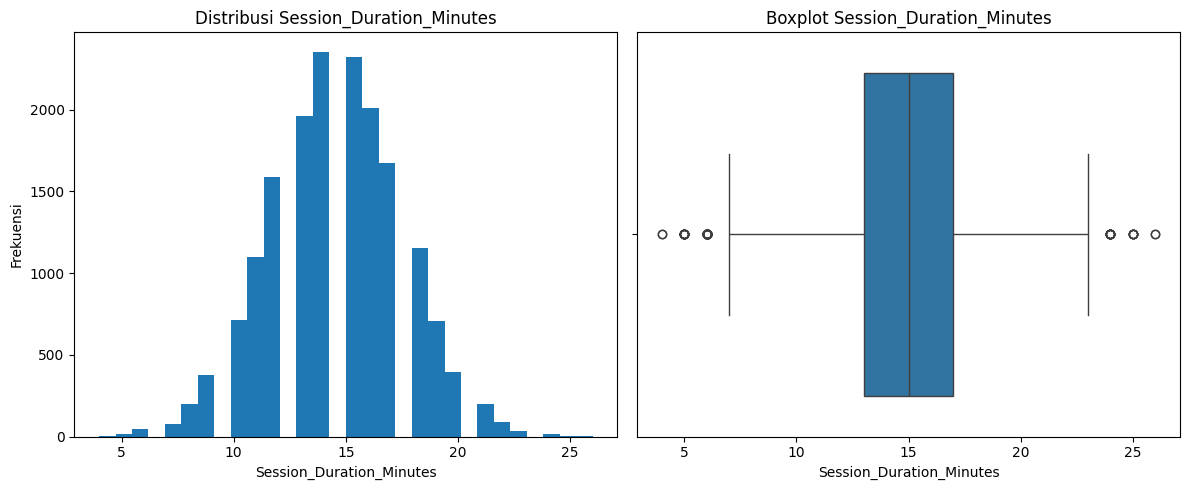

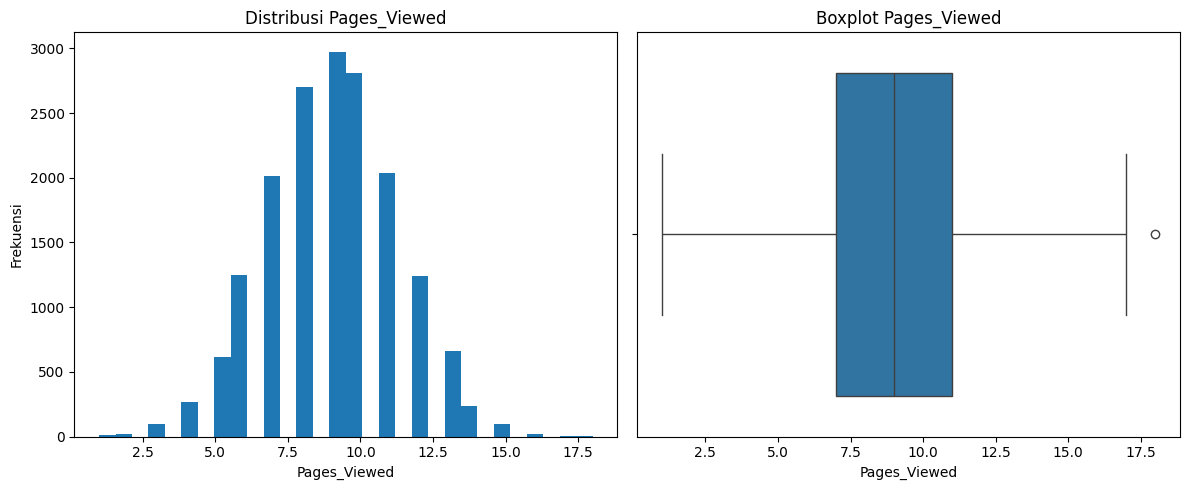

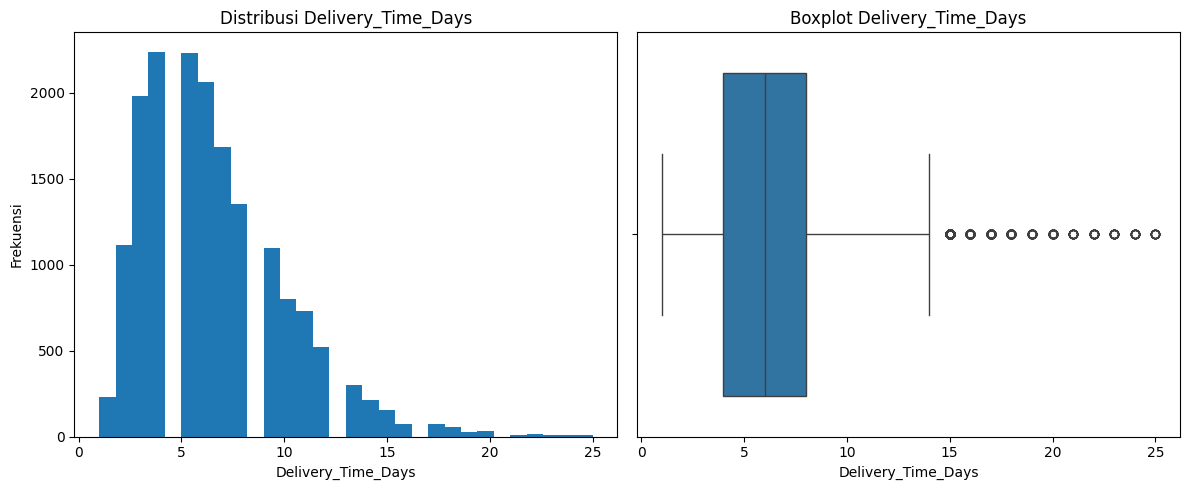

In [ ]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])

num_cols = ['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
            'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days']

for col in num_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")

    plt.tight_layout()
    plt.show()

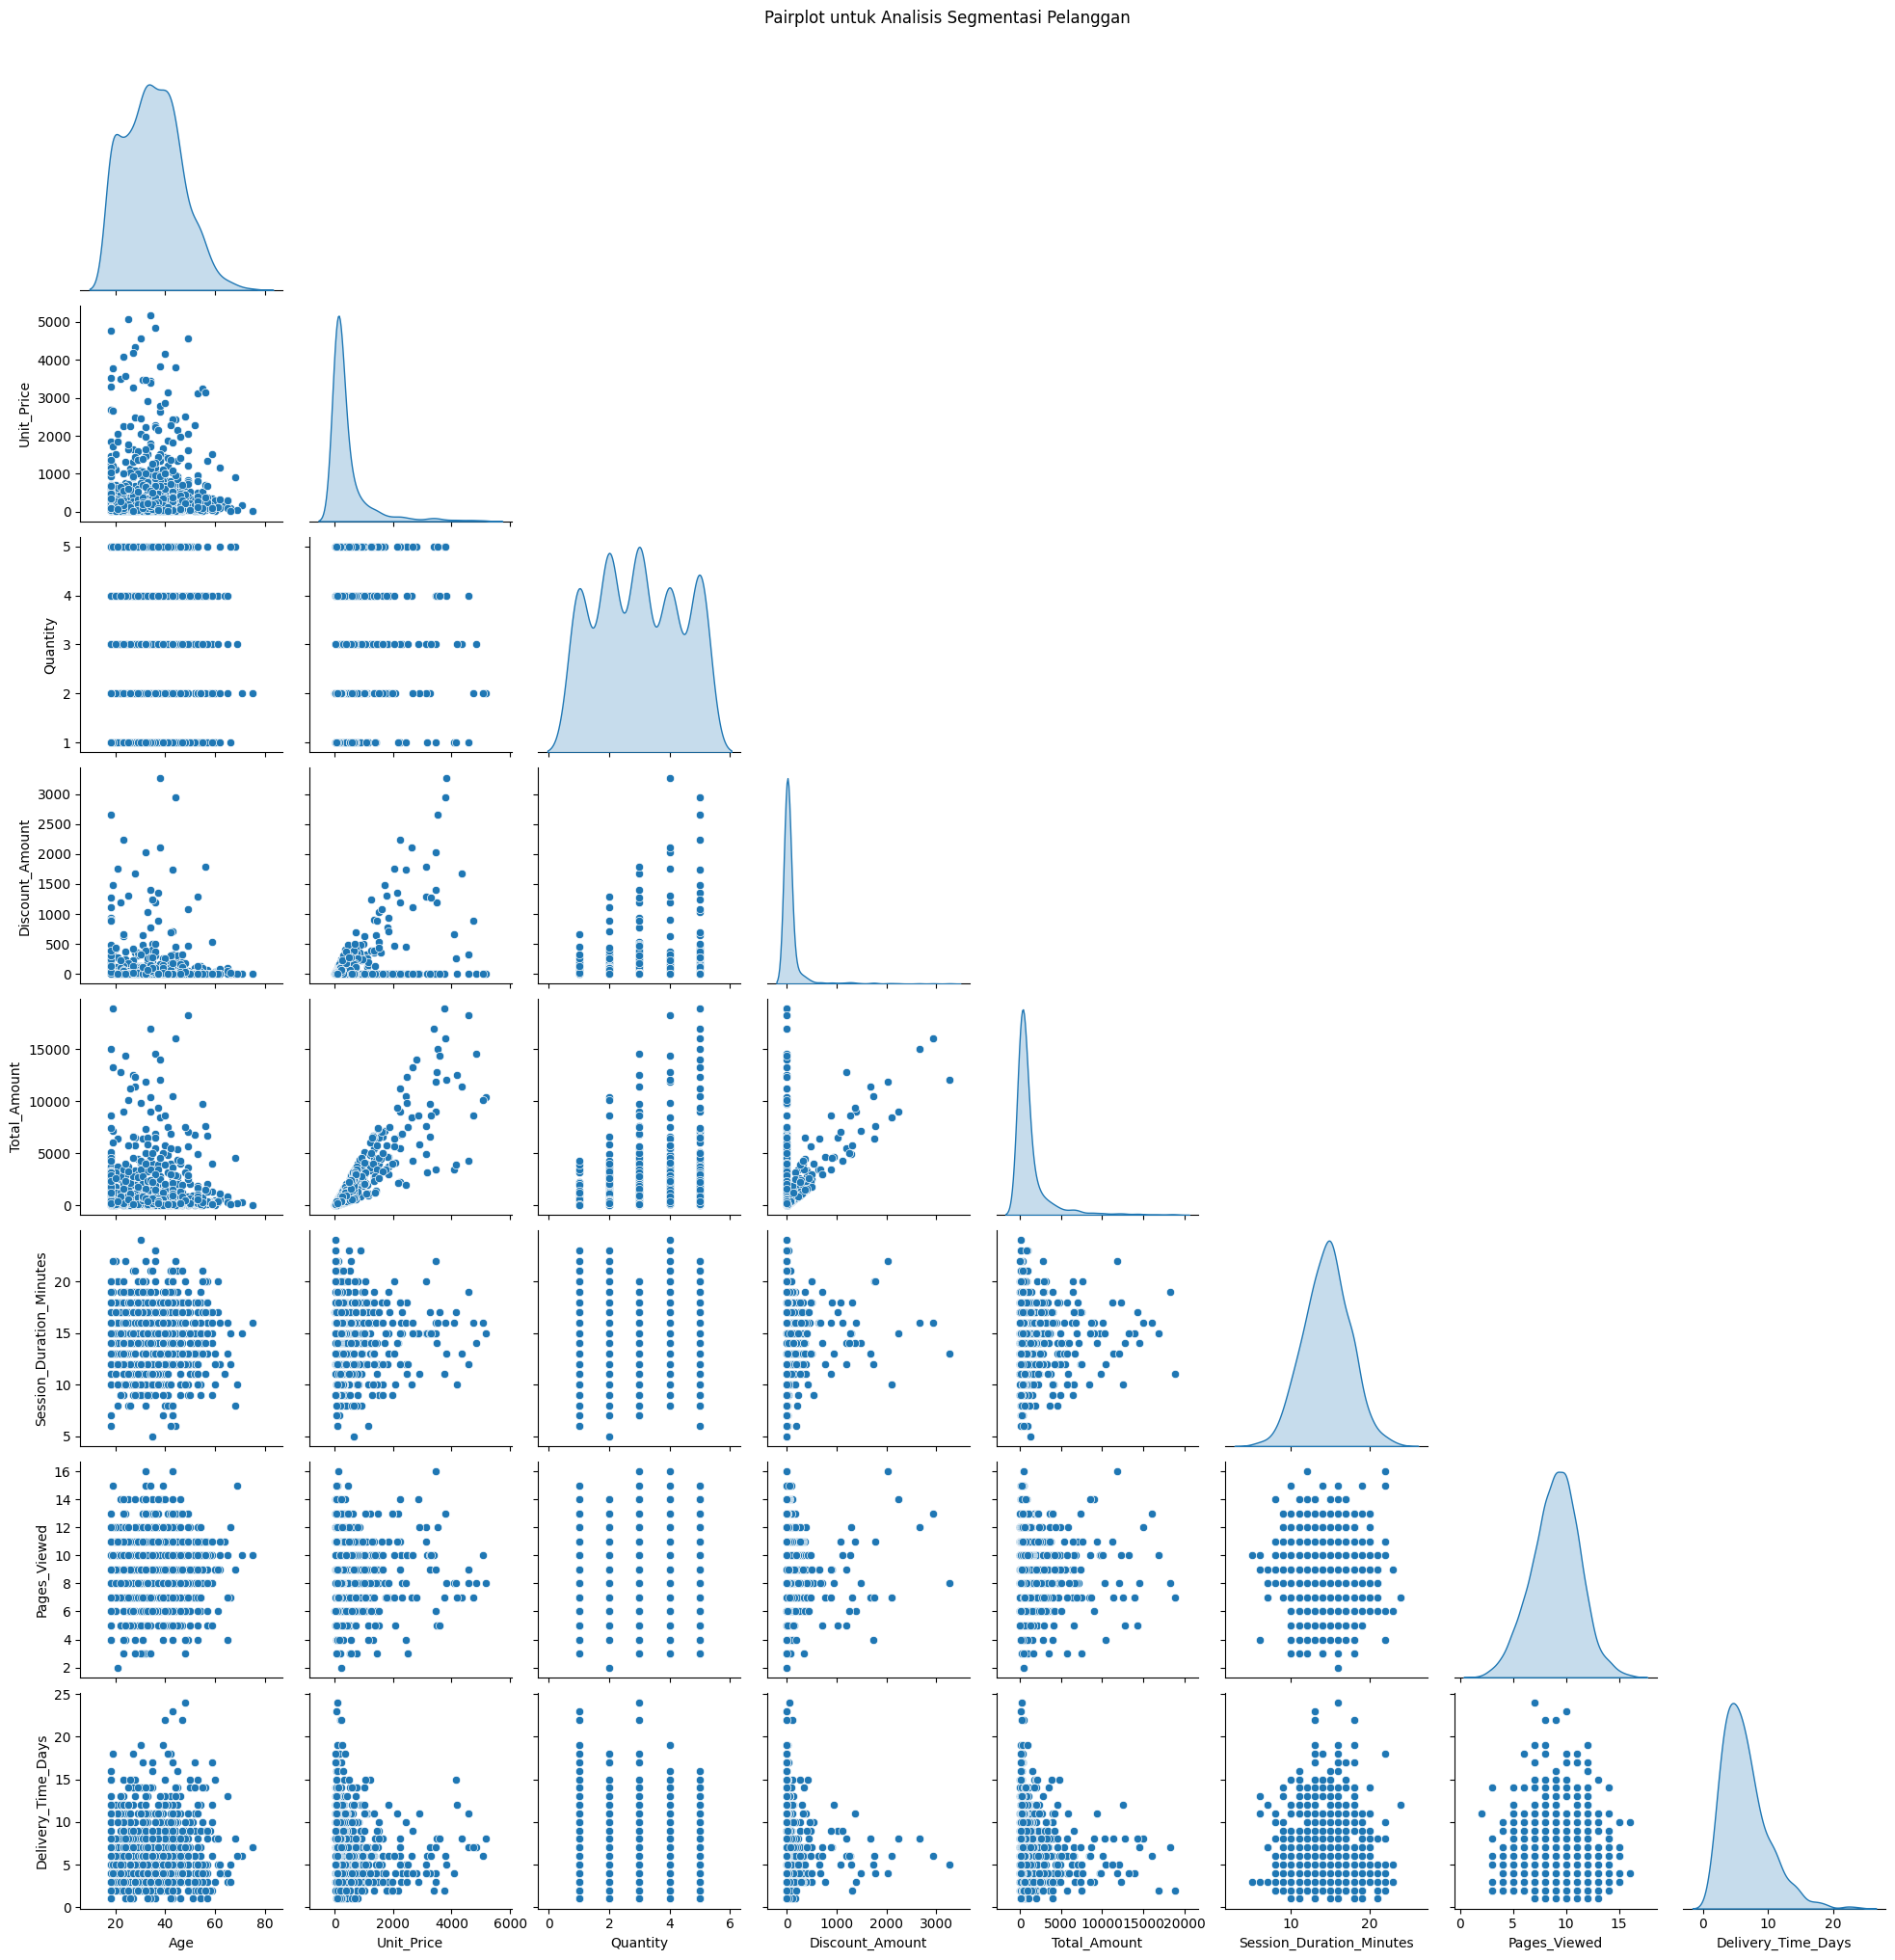

In [ ]:
# Ambil sample (biar ringan kalau datanya besar)
sample_df = df.sample(1000, random_state=42)

# Pairplot untuk melihat hubungan antar variabel numerik
sns.pairplot(sample_df[num_cols], diag_kind='kde', corner=True)
plt.suptitle("Pairplot untuk Analisis Segmentasi Pelanggan", y=1.02)
plt.show()

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Cek outlier untuk semua kolom numerik
print("\n=== OUTLIER DETECTION (IQR Method) ===")
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outlier")


=== OUTLIER DETECTION (IQR Method) ===
Age: 50 outlier
Unit_Price: 1757 outlier
Quantity: 0 outlier
Discount_Amount: 2789 outlier
Total_Amount: 1943 outlier
Session_Duration_Minutes: 85 outlier
Pages_Viewed: 1 outlier
Delivery_Time_Days: 475 outlier


**Data Preparation**


---

Memilih fitur

In [ ]:
features = [
    'Age',
    'Gender',
    'Product_Category',
    'Unit_Price',
    'Quantity',
    'Discount_Amount',
    'Total_Amount',
    'Payment_Method',
    'Session_Duration_Minutes',
    'Pages_Viewed',
    'Delivery_Time_Days',
    'Customer_Rating'
]
df_selected = df[features]
df_selected.head()

,Age,Gender,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
0,40,Male,Books,29.18,1,0.00,29.18,Digital Wallet,14,9,13,4
1,40,Male,Home & Garden,644.40,1,138.05,506.35,Credit Card,14,8,6,2
2,40,Male,Sports,332.82,5,0.00,1664.10,Credit Card,15,10,9,4
3,33,Male,Food,69.30,5,71.05,275.45,Digital Wallet,16,13,4,4
4,33,Male,Beauty,178.15,3,0.00,534.45,Credit Card,14,7,6,4


**Data Preparation**


---

Encoding menggunakan One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_cols = ['Gender', 'Product_Category', 'Payment_Method']

encoded = encoder.fit_transform(df_selected[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.concat([
    df_selected.drop(columns=categorical_cols).reset_index(drop=True),
    pd.DataFrame(encoded, columns=encoded_cols)
], axis=1)

df_encoded.head()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Gender_Male,...,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Food,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet
0,40,29.18,1,0.00,29.18,14,9,13,4,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,40,644.40,1,138.05,506.35,14,8,6,2,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,40,332.82,5,0.00,1664.10,15,10,9,4,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,33,69.30,5,71.05,275.45,16,13,4,4,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,33,178.15,3,0.00,534.45,14,7,6,4,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Data Preparation**


---

Normalisasi / Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_standard = StandardScaler()
df_standard_scaled = pd.DataFrame(
    scaler_standard.fit_transform(df_encoded),
    columns=df_encoded.columns
)

print("=== Standard Scaler (z-score) ===")
display(df_standard_scaled.head())

=== Standard Scaler (z-score) ===


,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Gender_Male,...,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Food,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet
0,0.457542,-0.579707,-1.419478,-0.289941,-0.529289,-0.183095,-0.001376,1.862132,0.089117,1.041753,...,-0.372153,-0.370312,-0.375109,-0.370721,-0.389720,-0.373785,-0.234408,-0.814642,-0.582656,2.050418
1,0.457542,0.272046,-1.419478,0.283600,-0.326959,-0.183095,-0.443875,-0.144354,-1.682724,1.041753,...,-0.372153,-0.370312,-0.375109,2.697446,-0.389720,-0.373785,-0.234408,1.227533,-0.582656,-0.487706
2,0.457542,-0.159327,1.403417,-0.289941,0.163953,0.158734,0.441124,0.715568,0.089117,1.041753,...,-0.372153,-0.370312,-0.375109,-0.370721,2.565945,-0.373785,-0.234408,1.227533,-0.582656,-0.487706
3,-0.176141,-0.524162,1.403417,0.005243,-0.424865,0.500563,1.768624,-0.717636,0.089117,1.041753,...,-0.372153,-0.370312,2.665894,-0.370721,-0.389720,-0.373785,-0.234408,-0.814642,-0.582656,2.050418
4,-0.176141,-0.373463,-0.008030,-0.289941,-0.315044,-0.183095,-0.886375,-0.144354,0.089117,1.041753,...,-0.372153,-0.370312,-0.375109,-0.370721,-0.389720,-0.373785,-0.234408,1.227533,-0.582656,-0.487706


# **Modeling**


---

Pada tahap Modeling, tujuan utama adalah melakukan segmentasi pelanggan berdasarkan perilaku belanja mereka menggunakan teknik clustering. Segmentasi ini berguna untuk memahami pola pembelian, menentukan strategi marketing, dan mengenali kelompok pelanggan dengan karakteristik berbeda.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

**Modeling**


---

# K-Means

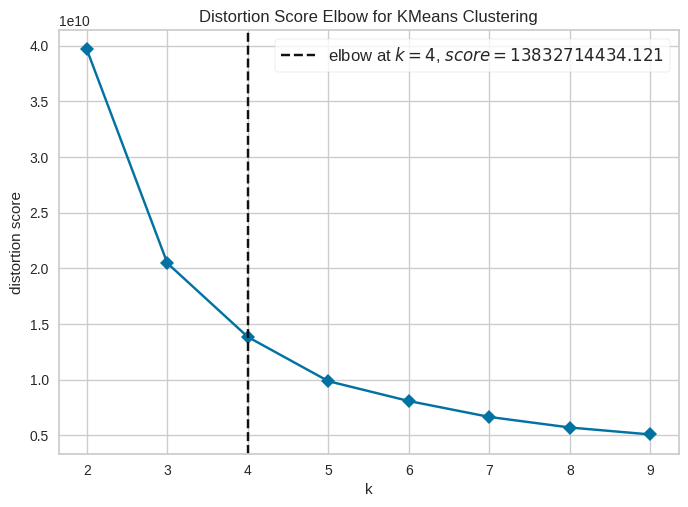

Elbow ditemukan pada k = 4


In [ ]:
# Elbow Method untuk menentukan nilai k optimal
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Data yang mau dipakai
df_kmeans = df_encoded

# Visualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10),  timings=False)

visualizer.fit(df_kmeans)
visualizer.show()

print("Elbow ditemukan pada k =", visualizer.elbow_value_)

In [ ]:
pca_model_kmeans = PCA(n_components=2)
pca_kmeans = pca_model_kmeans.fit_transform(df_kmeans)

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for modern KMeans
labels = kmeans.fit_predict(df_kmeans)
print(f"KMeans model trained on data with {df_kmeans.shape[1]} features.")
print(f"KMeans cluster centers shape: {kmeans.cluster_centers_.shape}")

KMeans model trained on data with 22 features.
KMeans cluster centers shape: (4, 22)


In [ ]:
centroids_raw = kmeans.cluster_centers_

df_selected['cluster_label'] = labels

print("Centroid (skala asli):")
print(pd.DataFrame(centroids_raw, columns=df_kmeans.columns))

# Display the head of df_selected with the new cluster labels
display(df_selected.head())

Centroid (skala asli):
         Age   Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0  34.936831   202.169639  2.870260        27.497020    470.810473   
1  34.645008  2360.798431  3.954041       418.197068   8075.978114   
2  34.751634  4165.195098  4.359477       690.911961  17063.389020   
3  35.085890  1110.573751  3.481391       180.047943   3094.401284   

   Session_Duration_Minutes  Pages_Viewed  Delivery_Time_Days  \
0                 14.553329      8.998480            6.515557   
1                 14.458003      9.110935            6.098257   
2                 14.653595      9.209150            6.444444   
3                 14.448262      8.988548            6.544376   

   Customer_Rating  Gender_Male  ...  Product_Category_Electronics  \
0         3.895658     0.481259  ...                      0.032562   
1         3.904913     0.489699  ...                      0.812995   
2         3.777778     0.464052  ...                      0.986928   
3         3.926789  

/tmp/ipython-input-2851682149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['cluster_label'] = labels


,Age,Gender,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,cluster_label
0,40,Male,Books,29.18,1,0.00,29.18,Digital Wallet,14,9,13,4,0
1,40,Male,Home & Garden,644.40,1,138.05,506.35,Credit Card,14,8,6,2,0
2,40,Male,Sports,332.82,5,0.00,1664.10,Credit Card,15,10,9,4,0
3,33,Male,Food,69.30,5,71.05,275.45,Digital Wallet,16,13,4,4,0
4,33,Male,Beauty,178.15,3,0.00,534.45,Credit Card,14,7,6,4,0


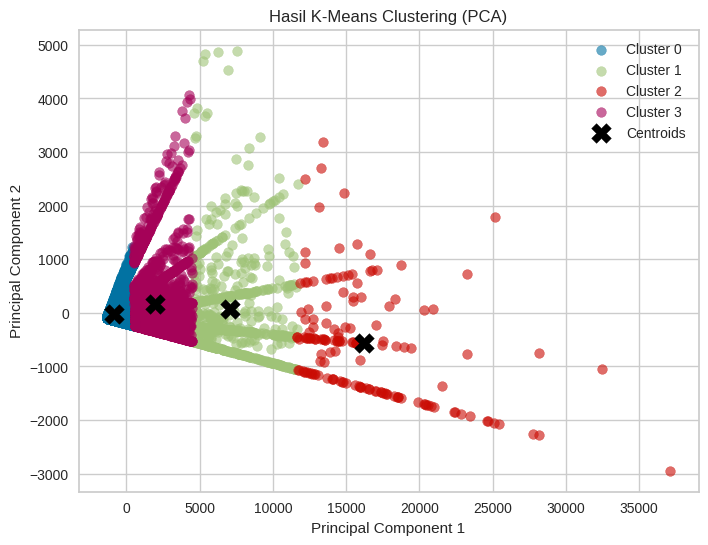

In [ ]:
transformed_centroids = pca_model_kmeans.transform(pd.DataFrame(kmeans.cluster_centers_, columns=df_kmeans.columns))

plt.figure(figsize=(8,6))
for i in range(n_clusters):
    plt.scatter(pca_kmeans[labels==i, 0], pca_kmeans[labels==i,1],
                label=f'Cluster {i}', alpha=0.6)
# centroid
plt.scatter(transformed_centroids[:,0], transformed_centroids[:,1],
            marker='X', s=200, c='black', label='Centroids', zorder=10)
plt.title('Hasil K-Means Clustering (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

**Modeling**


---

# K-Means NORMALISASI

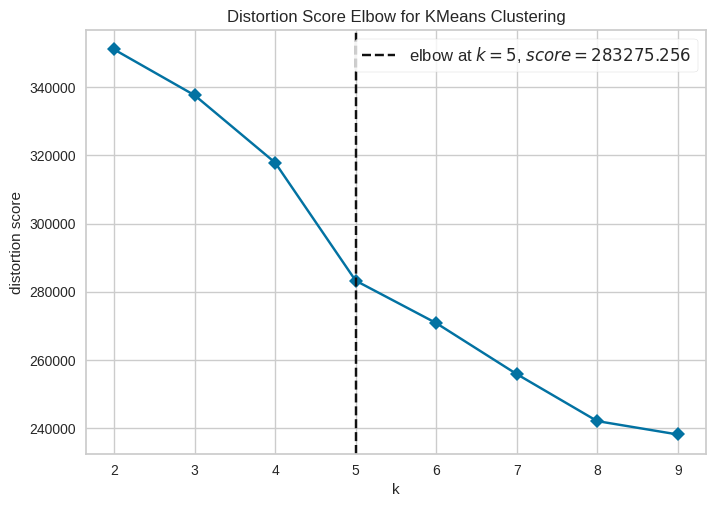

Elbow ditemukan pada k = 5


In [ ]:
# Elbow Method untuk menentukan nilai k optimal
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Data yang mau dipakai
df_kmeans_2 = df_standard_scaled

# Visualizer
model_2 = KMeans(random_state=42)
visualizer_2 = KElbowVisualizer(model, k=(2,10),  timings=False)

visualizer_2.fit(df_kmeans_2)
visualizer_2.show()

print("Elbow ditemukan pada k =", visualizer_2.elbow_value_)

In [ ]:
pca_model_kmeans_2 = PCA(n_components=2)
pca_kmeans_2 = pca_model_kmeans_2.fit_transform(df_kmeans_2)

In [ ]:
from sklearn.cluster import KMeans

n_clusters_2 = 5
kmeans_2 = KMeans(n_clusters=n_clusters_2, random_state=42, n_init=10) # Added n_init for modern KMeans
labels_2 = kmeans_2.fit_predict(df_kmeans_2)
print(f"KMeans model trained on data with {df_kmeans_2.shape[1]} features.")
print(f"KMeans cluster centers shape: {kmeans_2.cluster_centers_.shape}")

KMeans model trained on data with 22 features.
KMeans cluster centers shape: (5, 22)


In [ ]:
centroids_raw_2 = kmeans.cluster_centers_

df_selected['cluster_label'] = labels_2

print("Centroid (skala asli):")
print(pd.DataFrame(centroids_raw_2, columns=df_kmeans_2.columns))

# Display the head of df_selected with the new cluster labels
display(df_selected.head())

Centroid (skala asli):
         Age   Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0  34.936831   202.169639  2.870260        27.497020    470.810473   
1  34.645008  2360.798431  3.954041       418.197068   8075.978114   
2  34.751634  4165.195098  4.359477       690.911961  17063.389020   
3  35.085890  1110.573751  3.481391       180.047943   3094.401284   

   Session_Duration_Minutes  Pages_Viewed  Delivery_Time_Days  \
0                 14.553329      8.998480            6.515557   
1                 14.458003      9.110935            6.098257   
2                 14.653595      9.209150            6.444444   
3                 14.448262      8.988548            6.544376   

   Customer_Rating  Gender_Male  ...  Product_Category_Electronics  \
0         3.895658     0.481259  ...                      0.032562   
1         3.904913     0.489699  ...                      0.812995   
2         3.777778     0.464052  ...                      0.986928   
3         3.926789  

/tmp/ipython-input-2215862040.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['cluster_label'] = labels_2


,Age,Gender,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,cluster_label
0,40,Male,Books,29.18,1,0.00,29.18,Digital Wallet,14,9,13,4,2
1,40,Male,Home & Garden,644.40,1,138.05,506.35,Credit Card,14,8,6,2,0
2,40,Male,Sports,332.82,5,0.00,1664.10,Credit Card,15,10,9,4,1
3,33,Male,Food,69.30,5,71.05,275.45,Digital Wallet,16,13,4,4,0
4,33,Male,Beauty,178.15,3,0.00,534.45,Credit Card,14,7,6,4,0


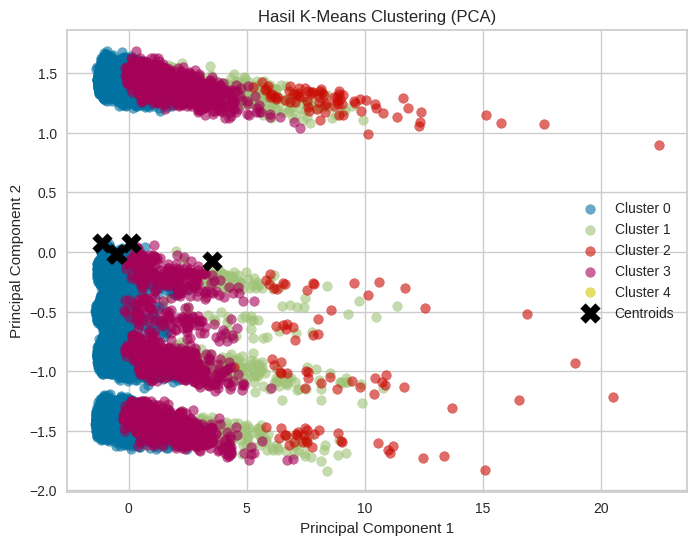

In [ ]:
transformed_centroids_2 = pca_model_kmeans_2.transform(pd.DataFrame(kmeans_2.cluster_centers_, columns=df_kmeans_2.columns))

plt.figure(figsize=(8,6))
for i in range(n_clusters_2):
    plt.scatter(pca_kmeans_2[labels==i, 0], pca_kmeans_2[labels==i,1],
                label=f'Cluster {i}', alpha=0.6)
# centroid
plt.scatter(transformed_centroids_2[:,0], transformed_centroids_2[:,1],
            marker='X', s=200, c='black', label='Centroids', zorder=10)
plt.title('Hasil K-Means Clustering (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

**Modeling**


---

# DBSCAN

In [ ]:
df_dbscan = df_standard_scaled
n_features_std = df_dbscan.shape[1]
min_samples_std = max(5, 2 * n_features_std)
min_samples_std = int(min_samples_std)

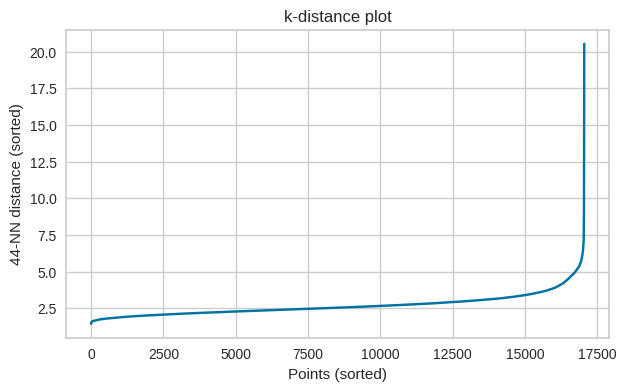

In [ ]:
k = min_samples_std if min_samples_std < df_dbscan.shape[0] else max(1, df_dbscan.shape[0]-1)
nn = NearestNeighbors(n_neighbors=k).fit(df_dbscan)
distances, _ = nn.kneighbors(df_dbscan)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,4))
plt.plot(k_distances)
plt.xlabel("Points (sorted)")
plt.ylabel(f"{k}-NN distance (sorted)")
plt.title("k-distance plot")
plt.show()

In [ ]:
epsilon = 5.0
print("min_samples:", min_samples_std, "epsilon:", epsilon)

min_samples: 44 epsilon: 5.0


In [ ]:
db = DBSCAN(eps=epsilon, min_samples=min_samples_std, n_jobs=-1)
clusterDB = db.fit_predict(df_dbscan)

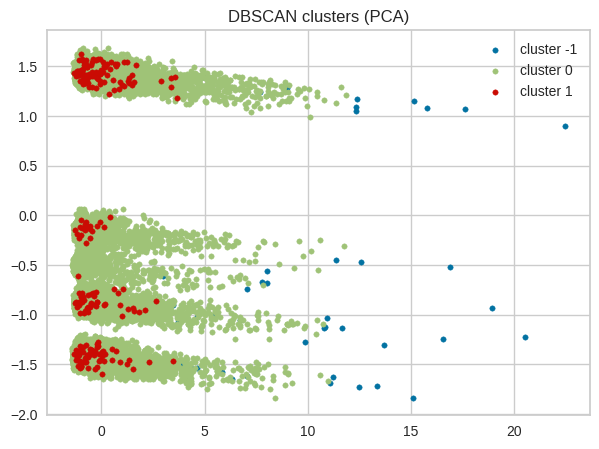

Hasil DBSCAN: 
n_points= 17049 
n_clusters= 2 
n_noise= 54


In [ ]:
pca = PCA(n_components=2).fit_transform(df_standard_scaled)
plt.figure(figsize=(7,5))
for lab in np.unique(clusterDB):
    mask = clusterDB == lab
    plt.scatter(pca[mask,0], pca[mask,1], label=f"cluster {lab}", s=15)
plt.title("DBSCAN clusters (PCA)")
plt.legend(loc='best', fontsize='small')
plt.show()

n_points = len(clusterDB)
n_noise = int((clusterDB == -1).sum())
n_clusters = len(set(clusterDB)) - (1 if -1 in clusterDB else 0)

print("Hasil DBSCAN: \nn_points=", n_points, "\nn_clusters=", n_clusters, "\nn_noise=", n_noise)

**Modeling**


---

# DBSCAN

In [ ]:
df_dbscan_2 = df_encoded.values
n_features_std_2 = df_dbscan_2.shape[1]
min_samples_std_2 = max(5, 2 * n_features_std_2)
min_samples_std_2 = int(min_samples_std_2)

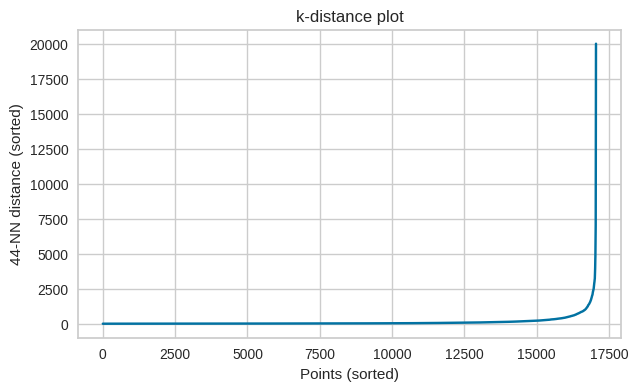

In [ ]:
k_2 = min_samples_std_2 if min_samples_std_2 < df_dbscan_2.shape[0] else max(1, df_dbscan_2.shape[0]-1)
nn = NearestNeighbors(n_neighbors=k_2).fit(df_dbscan_2)
distances, _ = nn.kneighbors(df_dbscan_2)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,4))
plt.plot(k_distances)
plt.xlabel("Points (sorted)")
plt.ylabel(f"{k_2}-NN distance (sorted)")
plt.title("k-distance plot")
plt.show()

In [ ]:
epsilon_2 = 15000.0
print("min_samples:", min_samples_std_2, "epsilon:", epsilon_2)

min_samples: 44 epsilon: 15000.0


In [ ]:
db_2 = DBSCAN(eps=epsilon_2, min_samples=min_samples_std_2, n_jobs=-1)
clusterDB_2 = db.fit_predict(df_dbscan_2)

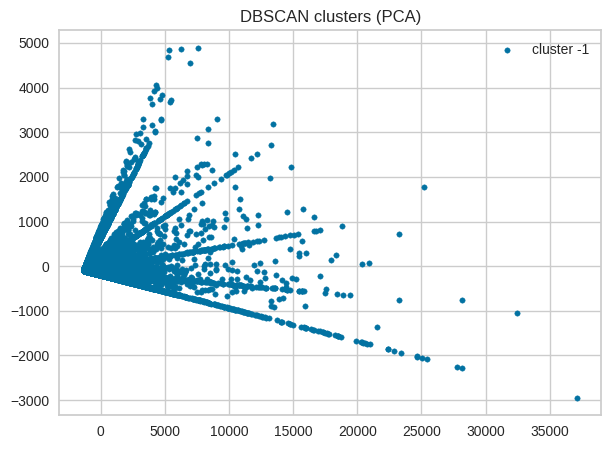

Hasil DBSCAN: 
n_points= 17049 
n_clusters= 0 
n_noise= 17049


In [ ]:
pca_2 = PCA(n_components=2).fit_transform(df_dbscan_2)
plt.figure(figsize=(7,5))
for lab in np.unique(clusterDB_2):
    mask = clusterDB_2 == lab
    plt.scatter(pca_2[mask,0], pca_2[mask,1], label=f"cluster {lab}", s=15)
plt.title("DBSCAN clusters (PCA)")
plt.legend(loc='best', fontsize='small')
plt.show()

n_points = len(clusterDB_2)
n_noise = int((clusterDB_2 == -1).sum())
n_clusters = len(set(clusterDB_2)) - (1 if -1 in clusterDB_2 else 0)

print("Hasil DBSCAN: \nn_points=", n_points, "\nn_clusters=", n_clusters, "\nn_noise=", n_noise)

# **Evaluation**


---

Tahap Evaluation bertujuan untuk menilai kualitas hasil clustering, memahami karakteristik setiap cluster, dan menentukan apakah model sudah memberikan segmentasi yang bermakna untuk bisnis.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

## **Evaluation - Kmeans Clustering**


---

**Sillhoute Score - KMeans Clustering**

In [ ]:
sil_kmeans = silhouette_score(df_kmeans, labels)
print("Silhouette Score (K-Means):", sil_kmeans)

sil_kmeans_2 = silhouette_score(df_kmeans_2, labels_2)
print("Silhouette Score (K-Means):", sil_kmeans_2)

Silhouette Score (K-Means): 0.7174134738707727
Silhouette Score (K-Means): 0.14324007963653196


**Kesimpulan:**

Hasil evaluasi Silhouette score berada dalam rentang -1 sampai 1, dengan kriteria

*  0.5 (sangat baik)
*  0.25 - 0.5 (cukup baik)
*  < 0.25 (kurang baik)

Dengan hasil **0.717** menunjukkan bahwa kualitas cluster KMEANS masuk kedalam kriteria Sangat Baik. Artinya:



*   Cluster cukup jelas dan terpisah secara umum.
*   Beberapa titik mungkin berada di area perbatasan antar cluster, sehingga tidak sepenuhnya optimal.
*   Karena KMeans tidak menggunakan normalisasi, fitur dengan skala besar (misal Total_Amount) cenderung mendominasi pembentukan cluster, sehingga interpretasi cluster harus memperhatikan pengaruh skala fitur.


**CHI (Calinski–Harabasz Index) - KMeans Clustering**

In [ ]:
chi_kmeans = calinski_harabasz_score(df_kmeans, labels)
print("Calinski-Harabasz Index (K-Means):", chi_kmeans)

chi_kmeans_2 = calinski_harabasz_score(df_kmeans_2, labels_2)
print("Calinski-Harabasz Index (K-Means):", chi_kmeans_2)

Calinski-Harabasz Index (K-Means): 37326.98139859615
Calinski-Harabasz Index (K-Means): 1389.4965260587435


**Kesimpulan:**

Untuk metode evaluasi CHI, semakin besar angkanya semakin padat dan berjauhan clusternya.

Hasil evaluasinya **37326.98** (Termasuk Tinggi), artinya:

*   Cluster yang terbentuk cukup padat di dalamnya (intra-cluster similarity tinggi).
*   Cluster cukup terpisah satu sama lain (inter-cluster distance besar).
*   Hasil ini mendukung bahwa segmentasi pelanggan menggunakan KMeans cukup baik dan dapat diandalkan untuk analisis perilaku pelanggan.



**DBI (Davies–Bouldin Index) - KMeans Clustering**

In [ ]:
dbi_kmeans = davies_bouldin_score(df_kmeans, labels)
print("Davies-Bouldin Index (K-Means):", dbi_kmeans)

dbi_kmeans_2 = davies_bouldin_score(df_kmeans_2, labels_2)
print("Davies-Bouldin Index (K-Means):", dbi_kmeans_2)

Davies-Bouldin Index (K-Means): 0.605238197169805
Davies-Bouldin Index (K-Means): 2.22470374827659


**Kesimpulan:**

Untuk hasil evaluasi metode DBI, jika angkanya semakin rendah semakin baik, Berikut keriterianya:

*   < 1 (Sangat Baik)
*   1-2 (Cukup baik)
*   2 (Buruk)

Dengan nilai **0.605** menunjukkan kualitas cluster KMeans berada dalam kategori Sangat Baik. Artinya:



*   Cluster memiliki intra-cluster similarity tinggi (titik dalam cluster cukup mirip).

*   Cluster memiliki inter-cluster distance yang cukup besar (cluster saling terpisah dengan baik).
*   Hasil ini mendukung bahwa segmentasi pelanggan menggunakan KMeans cukup representatif dan dapat diandalkan untuk analisis perilaku pelanggan.








### **Kesimpulan Keseluruhan:**
Secara keseluruhan, kualitas clustering K-Means dengan k = 4 termasuk sangat baik. Silhouette Score yang tinggi (0.717)menunjukkan bahwa cluster cukup jelas, dengan cohesion dan separation yang baik. CHI yang tinggi (37,326.98) menandakan cluster cukup padat di dalamnya dan terpisah dengan jelas antar cluster. Nilai DBI sebesar 0.605 mengindikasikan bahwa cluster memiliki intra-cluster similarity tinggi dan antar cluster terpisah dengan baik.

Dengan hasil ini, segmentasi pelanggan menggunakan K-Means terbukti membentuk cluster yang stabil dan representatif, sehingga dapat digunakan untuk analisis perilaku pelanggan dan strategi marketing.

## **Evaluation - DB Scan**


---

**Sillhoute Score - DB Scan**

In [ ]:
if len(set(clusterDB)) > 1:
    silhouette_dbscan = silhouette_score(df_dbscan, clusterDB)
    print("Silhouette Score (DBSCAN):", silhouette_dbscan)
else:
    print("Silhouette Score (DBSCAN): Tidak dapat dihitung karena cluster hanya satu atau seluruh data noise.")

if len(set(clusterDB_2)) > 1:
    silhouette_dbscan_2 = silhouette_score(df_dbscan_2, clusterDB_2)
    print("Silhouette Score (DBSCAN):", silhouette_dbscan_2)
else:
    print("Silhouette Score (DBSCAN): Tidak dapat dihitung karena cluster hanya satu atau seluruh data noise.")

Silhouette Score (DBSCAN): 0.3890448126853082
Silhouette Score (DBSCAN): Tidak dapat dihitung karena cluster hanya satu atau seluruh data noise.


**Kesimpulan:**

Hasil evaluasi Silhouette score berada dalam rentang -1 sampai 1, dengan kriteria


*   0.5 (sangat baik)
*   0.25 - 0.5 (cukup baik)
*   < 0.25 (kurang baik)

Dengan hasil **0.389** menunjukkan bahwa kualitas cluster DBScan masuk kedalam kriteria Cukup Baik. Artinya:


*   Data dalam cluster memilikan kemiripan satu sama lain (Cohesion Moderat).
*   Pemisahan antar cluster cukup jelas, tetapi belum terlalu optimal.
*   Ada kemungkinan beberapa titik berada di perbatasan *cluster*

**CHI (Calinski–Harabasz Index) - DB Scan**

In [ ]:
if len(set(clusterDB)) > 1:
    chi_dbscan = calinski_harabasz_score(df_dbscan, clusterDB)
    print("Calinski–Harabasz Index (DBSCAN):", chi_dbscan)
else:
    print("Calinski–Harabasz Index (DBSCAN): Tidak dapat dihitung untuk cluster tunggal atau seluruh data noise.")

if len(set(clusterDB_2)) > 1:
    chi_dbscan = calinski_harabasz_score(df_dbscan_2, clusterDB_2)
    print("Calinski–Harabasz Index (DBSCAN):", chi_dbscan)
else:
    print("Calinski–Harabasz Index (DBSCAN): Tidak dapat dihitung untuk cluster tunggal atau seluruh data noise.")


Calinski–Harabasz Index (DBSCAN): 510.93126702216244
Calinski–Harabasz Index (DBSCAN): Tidak dapat dihitung untuk cluster tunggal atau seluruh data noise.


**Kesimpulan:**

Untuk metode evaluasi CHI, semakin besar angkanya semakin padat dan berjauhan clusternya.

Hasil evaluasinya **510.93** (Termasuk Tinggi), artinya:

*   DBScan berhasil membentuk cluster yang cukup padat
*   Pemisah antar cluster cukup baik

**DBI (Davies–Bouldin Index) - DB Scan**

In [ ]:
if len(set(clusterDB)) > 1:
    dbi_dbscan = davies_bouldin_score(df_dbscan, clusterDB)
    print("Davies–Bouldin Index (DBSCAN):", dbi_dbscan)
else:
    print("Davies–Bouldin Index (DBSCAN): Tidak dapat dihitung karena cluster hanya satu.")

if len(set(clusterDB_2)) > 1:
    dbi_dbscan = davies_bouldin_score(df_dbscan_2, clusterDB_2)
    print("Davies–Bouldin Index (DBSCAN):", dbi_dbscan)
else:
    print("Davies–Bouldin Index (DBSCAN): Tidak dapat dihitung karena cluster hanya satu.")

Davies–Bouldin Index (DBSCAN): 1.372432579196678
Davies–Bouldin Index (DBSCAN): Tidak dapat dihitung karena cluster hanya satu.


**Kesimpulan:**

Untuk hasi evaluasi metode DBI, jika angkanya semakin rendah semakin baik, Berikut keriterianya:

*   < 1 (Sangat Baik)
*   1-2 (Cukup baik)
*   2 (Buruk)

Dengan nilai **1.37** menunjukkan kualitas cluster DBScan berada dalam kategori Cukup Baik. Artinya:

*   Cluster tidak terlalu tumpang tindih
*   Tapi masih ada beberapa cluster yang cukup mirip sehingga jaraknya tidak terlalu jauh






### **Kesimpulan Keseluruhan:**

Berdasarkan evaluasi DBSCAN, silhouette score sebesar 0.389 menunjukkan kualitas clustering yang cukup baik, dengan cohesion dan separation yang moderat. Nilai Calinski–Harabasz Index sebesar 510.93 juga menunjukkan bahwa cluster yang terbentuk relatif rapat dan terpisah dengan cukup jelas. Davies–Bouldin Index sebesar 1.37 termasuk kategori cukup baik, menandakan bahwa antar cluster tidak terlalu tumpang tindih. Secara keseluruhan, DBSCAN menghasilkan cluster yang stabil dan cukup representatif, meskipun masih dapat ditingkatkan melalui tuning parameter.

# **KESIMPULAN EVALUASI**



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data evaluasi yang sudah ada
evaluation_data = {
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index'],
    'K-Means': [sil_kmeans, chi_kmeans, dbi_kmeans],
    'DBSCAN': [silhouette_dbscan, chi_dbscan, dbi_dbscan]
}
df_evaluation = pd.DataFrame(evaluation_data)

# Melt DataFrame untuk plotting
df_melted = df_evaluation.melt(id_vars='Metric', var_name='Model', value_name='Score')


### Perbandingan Silhouette Score: K-Means vs DBSCAN

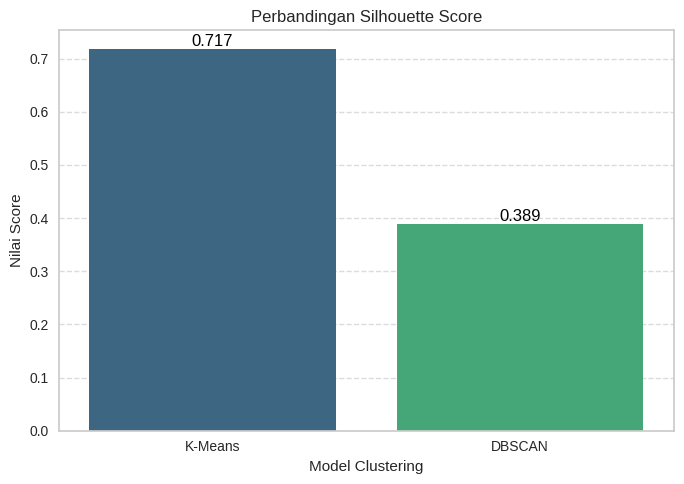

In [ ]:
metric_to_plot = 'Silhouette Score'
df_current_metric = df_melted[df_melted['Metric'] == metric_to_plot]

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Score', data=df_current_metric, hue='Model', palette='viridis', legend=False)
plt.title(f'Perbandingan {metric_to_plot}')
plt.ylabel('Nilai Score')
plt.xlabel('Model Clustering')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in df_current_metric.iterrows():
    plt.text(row.name % 2, row.Score, round(row.Score, 3), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Perbandingan Calinski-Harabasz Index: K-Means vs DBSCAN

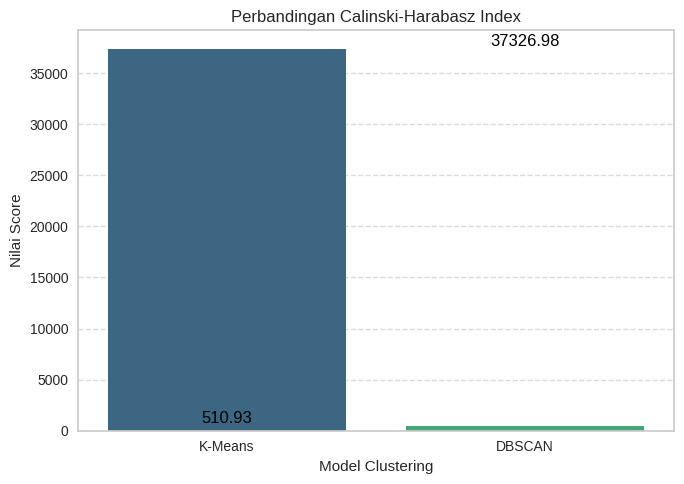

In [ ]:
metric_to_plot = 'Calinski-Harabasz Index'
df_current_metric = df_melted[df_melted['Metric'] == metric_to_plot]

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Score', data=df_current_metric, hue='Model', palette='viridis', legend=False)
plt.title(f'Perbandingan {metric_to_plot}')
plt.ylabel('Nilai Score')
plt.xlabel('Model Clustering')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in df_current_metric.iterrows():
    plt.text(row.name % 2, row.Score, round(row.Score, 2), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Perbandingan Davies-Bouldin Index: K-Means vs DBSCAN

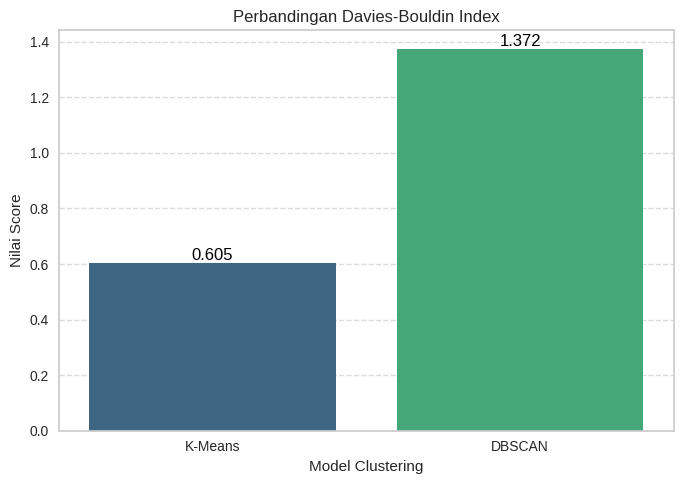

In [ ]:
metric_to_plot = 'Davies-Bouldin Index'
df_current_metric = df_melted[df_melted['Metric'] == metric_to_plot]

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Score', data=df_current_metric, hue='Model', palette='viridis', legend=False)
plt.title(f'Perbandingan {metric_to_plot}')
plt.ylabel('Nilai Score')
plt.xlabel('Model Clustering')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in df_current_metric.iterrows():
    plt.text(row.name % 2, row.Score, round(row.Score, 3), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
# Tabel perbandingan
print("Berikut adalah tabel perbandingan nilai evaluasi:")
display(df_evaluation)

Berikut adalah tabel perbandingan nilai evaluasi:


,Metric,K-Means,DBSCAN
0,Silhouette Score,0.717413,0.389045
1,Calinski-Harabasz Index,37326.981399,510.931267
2,Davies-Bouldin Index,0.605238,1.372433


### **Karakteristik Cluster K-Means**

Untuk memahami karakteristik dari setiap cluster, kita akan menghitung nilai rata-rata (untuk fitur numerik) dan mode (untuk fitur kategorikal) dari setiap fitur di dalam masing-masing cluster.

In [ ]:
# Daftar fitur numerik dan kategorikal
numerical_cols_summary = [
    'Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
    'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days',
    'Customer_Rating'
]

categorical_cols_summary = [
    'Gender', 'Product_Category', 'Payment_Method'
]

# Agregasi untuk fitur numerik (mean)
cluster_summary_num = df_selected.groupby('cluster_label')[numerical_cols_summary].mean()

# Fungsi untuk mencari nilai modus
def get_mode(series):
    return series.mode()[0] if not series.mode().empty else None

# Agregasi untuk fitur kategorikal (modus)
cluster_summary_cat = df_selected.groupby('cluster_label')[categorical_cols_summary].agg(get_mode)

# Gabungkan hasil agregasi numerik dan kategorikal
cluster_characteristics = pd.concat([cluster_summary_num, cluster_summary_cat], axis=1)

print("Karakteristik Setiap Cluster:")
display(cluster_characteristics)


Karakteristik Setiap Cluster:


,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Gender,Product_Category,Payment_Method
cluster_label,,,,,,,,,,,,
0,34.937328,202.132400,2.870025,27.469068,470.611625,14.553047,8.998336,6.515632,3.895571,Female,Beauty,Credit Card
1,34.645008,2360.798431,3.954041,418.197068,8075.978114,14.458003,9.110935,6.098257,3.904913,Female,Electronics,Credit Card
2,34.751634,4165.195098,4.359477,690.911961,17063.389020,14.653595,9.209150,6.444444,3.777778,Female,Electronics,Credit Card
3,35.082959,1110.041573,3.482223,180.081103,3093.379828,14.449939,8.989375,6.543931,3.927258,Female,Electronics,Credit Card


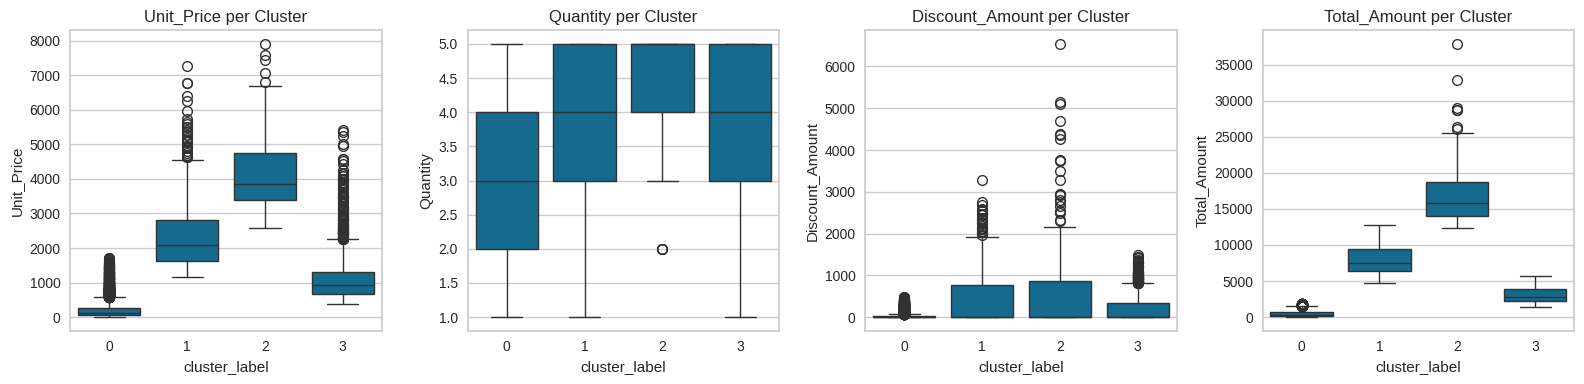

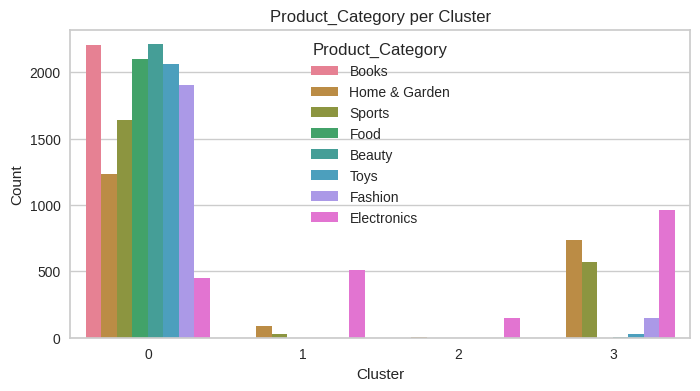

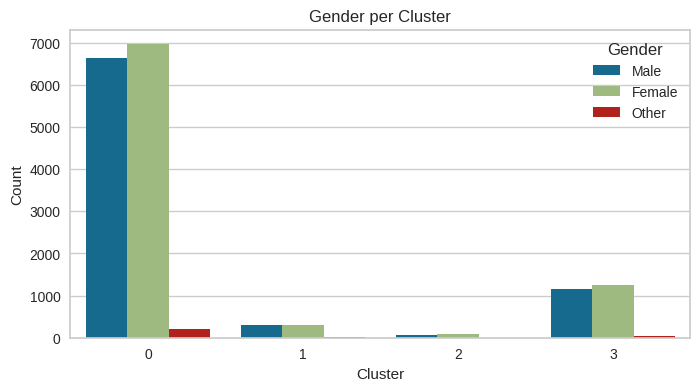

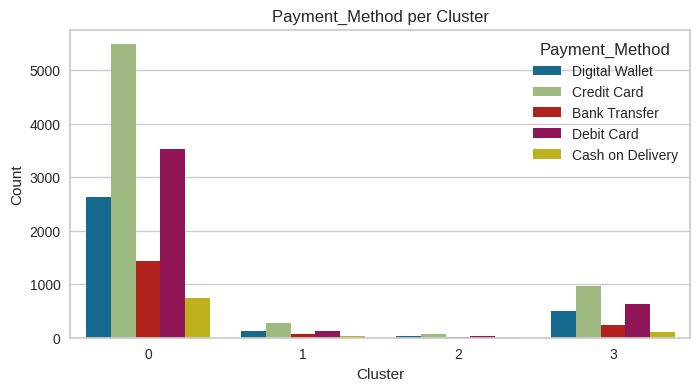

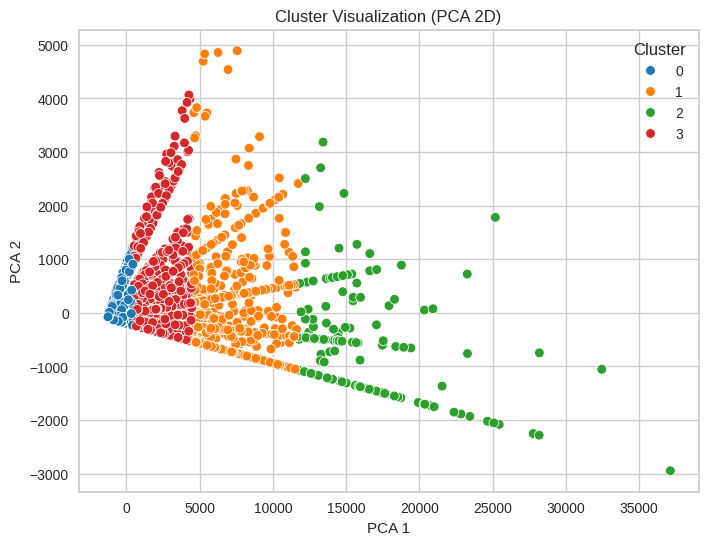

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Pastikan df_selected memiliki kolom 'cluster_label'

# Boxplot fitur numerik
numerical_cols_summary = ['Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount']
plt.figure(figsize=(16, 4))
for i, col in enumerate(numerical_cols_summary, 1):
    plt.subplot(1, len(numerical_cols_summary), i)
    sns.boxplot(x='cluster_label', y=col, data=df_selected)
    plt.title(f'{col} per Cluster')
plt.tight_layout()
plt.show()

# Bar chart untuk fitur kategorikal
categorical_cols_summary = ['Product_Category', 'Gender', 'Payment_Method']
for col in categorical_cols_summary:
    plt.figure(figsize=(8,4))
    sns.countplot(x='cluster_label', hue=col, data=df_selected)
    plt.title(f'{col} per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.legend(title=col)
    plt.show()

# 3Scatter plot PCA 2D
X_num = df_selected[numerical_cols_summary].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_num)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_selected['cluster_label'], palette='tab10')
plt.title('Cluster Visualization (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()
